<a href="https://colab.research.google.com/github/NaziaAfreen015/CSC791-DLBA/blob/main/bars_and_charts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import json
import re
from pathlib import Path
from typing import List, Dict, Any, Optional

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [19]:
# =========================================================
# Core loading / parsing helpers
# =========================================================

def load_tables(json_path: str) -> List[Dict[str, Any]]:
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)


def normalize_title(title: str) -> str:
    return re.sub(r"\s+", " ", str(title).strip().lower())


def find_table(tables: List[Dict[str, Any]], title_keyword: str) -> Dict[str, Any]:
    key = normalize_title(title_keyword)
    for table in tables:
        if key in normalize_title(table["title"]):
            return table
    raise ValueError(f"No table found with keyword: {title_keyword}")


def parse_value(x):
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)

    if not isinstance(x, str):
        return x

    x = x.strip()

    if x.endswith("%"):
        try:
            return float(x[:-1])
        except ValueError:
            return x

    try:
        return float(x)
    except ValueError:
        return x


def table_to_dataframe(table: Dict[str, Any]) -> pd.DataFrame:
    df = pd.DataFrame(table["data"], columns=table["headers"])
    for col in df.columns[1:]:
        df[col] = df[col].apply(parse_value)
    return df


def standardize_model_names(s: str) -> str:
    s = str(s).strip()
    replacements = {
        "Dense (Uncompressed)": "Dense",
        "Pruned (20% Sparsity)": "Pruned 20%",
        "Pruned (40% Sparsity)": "Pruned 40%",
        "Pruned (60% Sparsity)": "Pruned 60%",
        "Pruned (80% Sparsity)": "Pruned 80%",
        "Pruned 40%": "Pruned 40%",
        "Pruned 60%": "Pruned 60%",
        "Pruned 80%": "Pruned 80%",
        "Pruned 20%": "Pruned 20%",
    }
    return replacements.get(s, s)


def clean_first_column(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df[df.columns[0]] = df[df.columns[0]].apply(standardize_model_names)
    return df


def epsilon_column_lookup(df: pd.DataFrame) -> Dict[float, str]:
    mapping = {}
    for col in df.columns[1:]:
        m = re.search(r'([0-9]*\.[0-9]+)', str(col))
        if m:
            mapping[round(float(m.group(1)), 4)] = col
    return mapping


def get_epsilon_col(df: pd.DataFrame, epsilon: float) -> str:
    mapping = epsilon_column_lookup(df)
    eps = round(float(epsilon), 4)
    if eps not in mapping:
        raise ValueError(f"Epsilon {epsilon} not found. Available epsilons: {sorted(mapping.keys())}")
    return mapping[eps]


def melt_metric_table(
    df: pd.DataFrame,
    id_col: str,
    var_name: str = "epsilon",
    value_name: str = "value"
) -> pd.DataFrame:
    out = df.melt(id_vars=[id_col], var_name=var_name, value_name=value_name)
    out[var_name] = out[var_name].astype(str).str.extract(r'([0-9]*\.[0-9]+)').astype(float)
    return out


def ensure_dir(path: Optional[str]):
    if path is None:
        return
    Path(path).parent.mkdir(parents=True, exist_ok=True)


# =========================================================
# Low-level plotting helpers
# =========================================================

def finish_plot(output_path: Optional[str] = None, show: bool = True):
    plt.tight_layout()
    if output_path:
        ensure_dir(output_path)
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()


def grouped_bar_from_long(
    long_df: pd.DataFrame,
    x_col: str,
    series_col: str,
    value_col: str,
    title: str,
    xlabel: str,
    ylabel: str,
    figsize=(10, 5),
    rotation=0,
    output_path: Optional[str] = None,
    show: bool = True
):
    pivot_df = long_df.pivot(index=x_col, columns=series_col, values=value_col)

    x = np.arange(len(pivot_df.index))
    n_series = len(pivot_df.columns)
    width = 0.8 / max(n_series, 1)

    plt.figure(figsize=figsize)
    for i, col in enumerate(pivot_df.columns):
        plt.bar(
            x + i * width - (n_series - 1) * width / 2,
            pivot_df[col].values,
            width=width,
            label=col
        )

    plt.xticks(x, pivot_df.index, rotation=rotation)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    finish_plot(output_path, show)


def line_plot_from_long(
    long_df: pd.DataFrame,
    group_col: str,
    x_col: str,
    y_col: str,
    title: str,
    xlabel: str,
    ylabel: str,
    figsize=(10, 5),
    marker='o',
    output_path: Optional[str] = None,
    show: bool = True
):
    plt.figure(figsize=figsize)
    for name, subdf in long_df.groupby(group_col):
        subdf = subdf.sort_values(x_col)
        plt.plot(subdf[x_col], subdf[y_col], marker=marker, label=name)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    finish_plot(output_path, show)


def horizontal_bar(
    df: pd.DataFrame,
    label_col: str,
    value_col: str,
    title: str,
    xlabel: str,
    figsize=(8, 5),
    output_path: Optional[str] = None,
    show: bool = True
):
    plt.figure(figsize=figsize)
    plt.barh(df[label_col], df[value_col])
    plt.title(title)
    plt.xlabel(xlabel)
    finish_plot(output_path, show)


def stacked_bar(
    df: pd.DataFrame,
    x_col: str,
    stack_cols: List[str],
    title: str,
    xlabel: str,
    ylabel: str,
    rotation: int = 0,
    figsize=(10, 6),
    output_path: Optional[str] = None,
    show: bool = True
):
    plt.figure(figsize=figsize)
    bottom = np.zeros(len(df))

    for col in stack_cols:
        plt.bar(df[x_col], df[col], bottom=bottom, label=col)
        bottom += df[col].values

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation)
    plt.legend()
    finish_plot(output_path, show)


def heatmap_plot(
    df: pd.DataFrame,
    index_col: str,
    title: str,
    figsize=(8, 5),
    cmap: str = "viridis",
    output_path: Optional[str] = None,
    show: bool = True
):
    heat_df = df.set_index(index_col)

    plt.figure(figsize=figsize)
    plt.imshow(heat_df.values, aspect="auto", cmap=cmap)
    plt.colorbar(label="Value")
    plt.xticks(range(len(heat_df.columns)), heat_df.columns, rotation=45, ha="right")
    plt.yticks(range(len(heat_df.index)), heat_df.index)
    plt.title(title)
    finish_plot(output_path, show)


# =========================================================
# OLD graph codes
# =========================================================

def plot_clean_accuracy(tables: List[Dict[str, Any]], dataset_name: str,
                        output_path: Optional[str] = None, show: bool = True):
    table = find_table(tables, "Clean Accuracy by Model")
    df = clean_first_column(table_to_dataframe(table))

    long_df = df.rename(columns={df.columns[0]: "Model", df.columns[1]: "Clean Accuracy"})
    long_df = long_df.melt(id_vars="Model", var_name="Metric", value_name="Accuracy")

    grouped_bar_from_long(
        long_df,
        x_col="Model",
        series_col="Metric",
        value_col="Accuracy",
        title=f"{dataset_name}: Clean Accuracy by Model",
        xlabel="Model",
        ylabel="Accuracy",
        output_path=output_path,
        show=show
    )


def plot_adv_accuracy_initial_subset(tables: List[Dict[str, Any]], dataset_name: str,
                                     output_path: Optional[str] = None, show: bool = True):
    table = find_table(tables, "Adversarial accuracy on initially-correct subset")
    df = clean_first_column(table_to_dataframe(table))
    long_df = melt_metric_table(df, id_col=df.columns[0], var_name="epsilon", value_name="adv_acc")
    long_df = long_df.rename(columns={df.columns[0]: "Model"})

    line_plot_from_long(
        long_df=long_df,
        group_col="Model",
        x_col="epsilon",
        y_col="adv_acc",
        title=f"{dataset_name}: FGSM Adversarial Accuracy on Initially-Correct Subset",
        xlabel="Epsilon",
        ylabel="Adversarial Accuracy",
        output_path=output_path,
        show=show
    )


def plot_attack_success_rate(tables: List[Dict[str, Any]], dataset_name: str,
                             output_path: Optional[str] = None, show: bool = True):
    table = find_table(tables, "Attack success rate")
    df = clean_first_column(table_to_dataframe(table))
    long_df = melt_metric_table(df, id_col=df.columns[0], var_name="epsilon", value_name="asr")
    long_df = long_df.rename(columns={df.columns[0]: "Model"})

    line_plot_from_long(
        long_df=long_df,
        group_col="Model",
        x_col="epsilon",
        y_col="asr",
        title=f"{dataset_name}: FGSM Attack Success Rate",
        xlabel="Epsilon",
        ylabel="ASR",
        output_path=output_path,
        show=show
    )


def plot_transfer_heatmap(tables: List[Dict[str, Any]], title_keyword: str, dataset_name: str,
                          output_path: Optional[str] = None, show: bool = True):
    table = find_table(tables, title_keyword)
    df = table_to_dataframe(table)

    heatmap_plot(
        df=df,
        index_col=df.columns[0],
        title=f"{dataset_name}: {table['title']}",
        output_path=output_path,
        show=show
    )


def plot_transfer_lines(tables: List[Dict[str, Any]], title_keyword: str, dataset_name: str,
                        output_path: Optional[str] = None, show: bool = True):
    table = find_table(tables, title_keyword)
    df = table_to_dataframe(table)
    long_df = melt_metric_table(df, id_col=df.columns[0], var_name="epsilon", value_name="value")
    long_df = long_df.rename(columns={df.columns[0]: "Group"})

    line_plot_from_long(
        long_df=long_df,
        group_col="Group",
        x_col="epsilon",
        y_col="value",
        title=f"{dataset_name}: {table['title']}",
        xlabel="Epsilon",
        ylabel="Value",
        output_path=output_path,
        show=show
    )


def plot_weighted_region_sparsity(tables: List[Dict[str, Any]], dataset_name: str,
                                  output_path: Optional[str] = None, show: bool = True):
    candidates = [
        "Weighted region sparsity",
        "Weighted pruning by model region"
    ]
    table = None
    for key in candidates:
        try:
            table = find_table(tables, key)
            break
        except ValueError:
            pass
    if table is None:
        raise ValueError("Weighted region sparsity table not found.")

    df = table_to_dataframe(table)
    long_df = df.melt(id_vars=[df.columns[0]], var_name="Global Sparsity", value_name="Region Sparsity")
    long_df = long_df.rename(columns={df.columns[0]: "Region"})

    grouped_bar_from_long(
        long_df,
        x_col="Region",
        series_col="Global Sparsity",
        value_col="Region Sparsity",
        title=f"{dataset_name}: Weighted Pruning by Model Region",
        xlabel="Region",
        ylabel="Sparsity (%)",
        output_path=output_path,
        show=show
    )


def plot_parameter_share(tables: List[Dict[str, Any]], dataset_name: str,
                         output_path: Optional[str] = None, show: bool = True):
    table = find_table(tables, "Parameter share")
    df = table_to_dataframe(table)

    horizontal_bar(
        df=df,
        label_col=df.columns[0],
        value_col=df.columns[1],
        title=f"{dataset_name}: Parameter Share by Region",
        xlabel="Share of Total Parameters (%)",
        output_path=output_path,
        show=show
    )


def plot_pruning_concentration(tables: List[Dict[str, Any]], dataset_name: str,
                               output_path: Optional[str] = None, show: bool = True):
    table = find_table(tables, "Pruning concentration")
    df = table_to_dataframe(table)
    long_df = df.melt(id_vars=[df.columns[0]], var_name="Global Sparsity", value_name="Share of Pruned Weights")
    long_df = long_df.rename(columns={df.columns[0]: "Region"})

    grouped_bar_from_long(
        long_df,
        x_col="Region",
        series_col="Global Sparsity",
        value_col="Share of Pruned Weights",
        title=f"{dataset_name}: Pruning Concentration by Region",
        xlabel="Region",
        ylabel="Share of All Pruned Weights (%)",
        output_path=output_path,
        show=show
    )


def plot_example_breakdown_stacked(tables: List[Dict[str, Any]], title_keyword: str, dataset_name: str,
                                   output_path: Optional[str] = None, show: bool = True):
    table = find_table(tables, title_keyword)
    df = table_to_dataframe(table)

    state_cols = [c for c in df.columns if str(c).startswith("examples_")]
    if "epsilon" not in df.columns:
        raise ValueError("Example breakdown table does not contain 'epsilon' column.")

    df["epsilon"] = df["epsilon"].astype(str)

    stacked_bar(
        df=df,
        x_col="epsilon",
        stack_cols=state_cols,
        title=f"{dataset_name}: {table['title']}",
        xlabel="Epsilon",
        ylabel="Count",
        output_path=output_path,
        show=show
    )
def plot_adversarial_accuracy_drop_vs_sparsity(
    tables: List[Dict[str, Any]],
    dataset_name: str,
    output_path: Optional[str] = None,
    show: bool = True
):
    # -----------------------------
    # Find needed tables
    # -----------------------------
    clean_table = find_table(tables, "Clean Accuracy by Model")
    adv_table = find_table(tables, "Adversarial accuracy (same-model adversarial examples)")

    # -----------------------------
    # Convert to dataframes
    # -----------------------------
    clean_df = clean_first_column(table_to_dataframe(clean_table))
    adv_df = clean_first_column(table_to_dataframe(adv_table))

    # Standardize column names
    clean_df = clean_df.rename(columns={
        clean_df.columns[0]: "Model",
        clean_df.columns[1]: "clean_acc"
    })
    adv_df = adv_df.rename(columns={adv_df.columns[0]: "Model"})

    # -----------------------------
    # Add sparsity column
    # Dense -> 0, Pruned xx% -> xx
    # -----------------------------
    def model_to_sparsity(model_name: str) -> float:
        model_name = str(model_name).strip()
        if model_name == "Dense":
            return 0.0
        m = re.search(r'(\d+)', model_name)
        if m:
            return float(m.group(1))
        raise ValueError(f"Could not parse sparsity from model name: {model_name}")

    clean_df["sparsity"] = clean_df["Model"].apply(model_to_sparsity)

    # -----------------------------
    # Melt adversarial table to long format
    # -----------------------------
    adv_long = melt_metric_table(
        adv_df,
        id_col="Model",
        var_name="epsilon",
        value_name="adv_acc"
    )

    # -----------------------------
    # Merge clean accuracy with adversarial accuracy
    # -----------------------------
    merged = adv_long.merge(
        clean_df[["Model", "clean_acc", "sparsity"]],
        on="Model",
        how="left"
    )

    # -----------------------------
    # Compute drop
    # drop = clean accuracy - adversarial accuracy
    # -----------------------------
    merged["acc_drop"] = merged["clean_acc"] - merged["adv_acc"]

    # -----------------------------
    # Plot
    # group = epsilon
    # x = sparsity
    # y = acc_drop
    # -----------------------------
    line_plot_from_long(
        long_df=merged,
        group_col="epsilon",
        x_col="sparsity",
        y_col="acc_drop",
        title=f"{dataset_name}: Adversarial Accuracy Drop vs Sparsity across Epsilon",
        xlabel="Sparsity (%)",
        ylabel="Adversarial Accuracy Drop",
        output_path=output_path,
        show=show
    )

def run_core_old_plots(tables: List[Dict[str, Any]], dataset_name: str,
                       out_dir: Optional[str] = None, show: bool = True):
    prefix = None if out_dir is None else Path(out_dir)

    # plot_clean_accuracy(
    #     tables, dataset_name,
    #     output_path=None if prefix is None else str(prefix / "old_clean_accuracy.png"),
    #     show=show
    # )
    # plot_adv_accuracy_initial_subset(
    #     tables, dataset_name,
    #     output_path=None if prefix is None else str(prefix / "old_adv_acc_init_subset.png"),
    #     show=show
    # )
    plot_attack_success_rate(
        tables, dataset_name,
        output_path=None if prefix is None else str(prefix / "old_attack_success_rate.png"),
        show=show
    )


    plot_adversarial_accuracy_drop_vs_sparsity(
        tables,
        dataset_name
    )
    # plot_transfer_heatmap(
    #     tables, "Transferability: Dense → Pruned", dataset_name,
    #     output_path=None if prefix is None else str(prefix / "old_transfer_heatmap_dense_to_pruned.png"),
    #     show=show
    # )
    # plot_transfer_heatmap(
    #     tables, "Transferability: Pruned → Dense", dataset_name,
    #     output_path=None if prefix is None else str(prefix / "old_transfer_heatmap_pruned_to_dense.png"),
    #     show=show
    # )
    plot_transfer_lines(
        tables, "Transferability: Dense → Pruned", dataset_name,
        output_path=None if prefix is None else str(prefix / "old_transfer_lines_dense_to_pruned.png"),
        show=show
    )
    plot_transfer_lines(
        tables, "Transferability: Pruned → Dense", dataset_name,
        output_path=None if prefix is None else str(prefix / "old_transfer_lines_pruned_to_dense.png"),
        show=show
    )
    # plot_weighted_region_sparsity(
    #     tables, dataset_name,
    #     output_path=None if prefix is None else str(prefix / "old_weighted_region_sparsity.png"),
    #     show=show
    # )
    # plot_parameter_share(
    #     tables, dataset_name,
    #     output_path=None if prefix is None else str(prefix / "old_parameter_share.png"),
    #     show=show
    # )
    # plot_pruning_concentration(
    #     tables, dataset_name,
    #     output_path=None if prefix is None else str(prefix / "old_pruning_concentration.png"),
    #     show=show
    # )


# =========================================================
# NEW graph codes
# =========================================================

def plot_clean_vs_fgsm_at_epsilon(tables: List[Dict[str, Any]], dataset_name: str, epsilon: float,
                                  output_path: Optional[str] = None, show: bool = True):
    clean_table = find_table(tables, "Clean Accuracy by Model")
    fgsm_table = find_table(tables, "Adversarial accuracy (same-model adversarial examples)")

    clean_df = clean_first_column(table_to_dataframe(clean_table))
    fgsm_df = clean_first_column(table_to_dataframe(fgsm_table))

    model_col_clean = clean_df.columns[0]
    model_col_fgsm = fgsm_df.columns[0]
    eps_col = get_epsilon_col(fgsm_df, epsilon)

    merged = pd.merge(
        clean_df[[model_col_clean, clean_df.columns[1]]].rename(
            columns={model_col_clean: "Model", clean_df.columns[1]: "Clean"}
        ),
        fgsm_df[[model_col_fgsm, eps_col]].rename(
            columns={model_col_fgsm: "Model", eps_col: "FGSM"}
        ),
        on="Model"
    )

    long_df = merged.melt(id_vars="Model", var_name="Metric", value_name="Accuracy")

    grouped_bar_from_long(
        long_df,
        x_col="Model",
        series_col="Metric",
        value_col="Accuracy",
        title=f"{dataset_name}: Clean vs FGSM Accuracy @ ε={epsilon}",
        xlabel="Model",
        ylabel="Accuracy",
        output_path=output_path,
        show=show
    )


def plot_clean_vs_fgsm_vs_init_subset(tables: List[Dict[str, Any]], dataset_name: str, epsilon: float,
                                      output_path: Optional[str] = None, show: bool = True):
    clean_table = find_table(tables, "Clean Accuracy by Model")
    fgsm_table = find_table(tables, "Adversarial accuracy (same-model adversarial examples)")
    init_table = find_table(tables, "Adversarial accuracy on initially-correct subset")

    clean_df = clean_first_column(table_to_dataframe(clean_table))
    fgsm_df = clean_first_column(table_to_dataframe(fgsm_table))
    init_df = clean_first_column(table_to_dataframe(init_table))

    clean_col = clean_df.columns[1]
    fgsm_col = get_epsilon_col(fgsm_df, epsilon)
    init_col = get_epsilon_col(init_df, epsilon)

    merged = clean_df[[clean_df.columns[0], clean_col]].rename(
        columns={clean_df.columns[0]: "Model", clean_col: "Clean"}
    )
    merged = merged.merge(
        fgsm_df[[fgsm_df.columns[0], fgsm_col]].rename(
            columns={fgsm_df.columns[0]: "Model", fgsm_col: "FGSM Full Test"}
        ),
        on="Model"
    )
    merged = merged.merge(
        init_df[[init_df.columns[0], init_col]].rename(
            columns={init_df.columns[0]: "Model", init_col: "FGSM Init-Correct"}
        ),
        on="Model"
    )

    long_df = merged.melt(id_vars="Model", var_name="Metric", value_name="Accuracy")

    grouped_bar_from_long(
        long_df,
        x_col="Model",
        series_col="Metric",
        value_col="Accuracy",
        title=f"{dataset_name}: Clean vs FGSM vs Init-Correct FGSM @ ε={epsilon}",
        xlabel="Model",
        ylabel="Accuracy",
        output_path=output_path,
        show=show
    )


def plot_clean_drop_at_epsilon(tables: List[Dict[str, Any]], dataset_name: str, epsilon: float,
                               output_path: Optional[str] = None, show: bool = True):
    clean_table = find_table(tables, "Clean Accuracy by Model")
    fgsm_table = find_table(tables, "Adversarial accuracy (same-model adversarial examples)")

    clean_df = clean_first_column(table_to_dataframe(clean_table))
    fgsm_df = clean_first_column(table_to_dataframe(fgsm_table))

    clean_col = clean_df.columns[1]
    fgsm_col = get_epsilon_col(fgsm_df, epsilon)

    merged = clean_df[[clean_df.columns[0], clean_col]].rename(
        columns={clean_df.columns[0]: "Model", clean_col: "Clean"}
    )
    merged = merged.merge(
        fgsm_df[[fgsm_df.columns[0], fgsm_col]].rename(
            columns={fgsm_df.columns[0]: "Model", fgsm_col: "FGSM"}
        ),
        on="Model"
    )
    merged["Drop"] = merged["Clean"] - merged["FGSM"]

    plt.figure(figsize=(10, 5))
    plt.bar(merged["Model"], merged["Drop"])
    plt.xlabel("Model")
    plt.ylabel("Accuracy Drop")
    plt.title(f"{dataset_name}: Clean-to-FGSM Accuracy Drop @ ε={epsilon}")
    finish_plot(output_path, show)


def plot_retention_at_epsilon(tables: List[Dict[str, Any]], dataset_name: str, epsilon: float,
                              output_path: Optional[str] = None, show: bool = True):
    clean_table = find_table(tables, "Clean Accuracy by Model")
    fgsm_table = find_table(tables, "Adversarial accuracy (same-model adversarial examples)")

    clean_df = clean_first_column(table_to_dataframe(clean_table))
    fgsm_df = clean_first_column(table_to_dataframe(fgsm_table))

    clean_col = clean_df.columns[1]
    fgsm_col = get_epsilon_col(fgsm_df, epsilon)

    merged = clean_df[[clean_df.columns[0], clean_col]].rename(
        columns={clean_df.columns[0]: "Model", clean_col: "Clean"}
    )
    merged = merged.merge(
        fgsm_df[[fgsm_df.columns[0], fgsm_col]].rename(
            columns={fgsm_df.columns[0]: "Model", fgsm_col: "FGSM"}
        ),
        on="Model"
    )
    merged["Retention"] = merged["FGSM"] / merged["Clean"]

    plt.figure(figsize=(10, 5))
    plt.bar(merged["Model"], merged["Retention"])
    plt.xlabel("Model")
    plt.ylabel("FGSM / Clean")
    plt.title(f"{dataset_name}: Relative Robustness Retention @ ε={epsilon}")
    finish_plot(output_path, show)


def plot_fgsm_accuracy_curve(tables: List[Dict[str, Any]], dataset_name: str,
                             output_path: Optional[str] = None, show: bool = True):
    fgsm_table = find_table(tables, "Adversarial accuracy (same-model adversarial examples)")
    df = clean_first_column(table_to_dataframe(fgsm_table))

    model_col = df.columns[0]
    rows = []

    for _, row in df.iterrows():
        for col in df.columns[1:]:
            m = re.search(r'([0-9]*\.[0-9]+)', str(col))
            if not m:
                continue
            eps = float(m.group(1))
            rows.append({
                "Model": row[model_col],
                "Epsilon": eps,
                "FGSM Accuracy": row[col]
            })

    long_df = pd.DataFrame(rows)

    line_plot_from_long(
        long_df,
        group_col="Model",
        x_col="Epsilon",
        y_col="FGSM Accuracy",
        title=f"{dataset_name}: FGSM Adversarial Accuracy vs Epsilon",
        xlabel="Epsilon",
        ylabel="Adversarial Accuracy",
        output_path=output_path,
        show=show
    )


def plot_init_subset_fgsm_curve(tables: List[Dict[str, Any]], dataset_name: str,
                                output_path: Optional[str] = None, show: bool = True):
    init_table = find_table(tables, "Adversarial accuracy on initially-correct subset")
    df = clean_first_column(table_to_dataframe(init_table))

    model_col = df.columns[0]
    rows = []

    for _, row in df.iterrows():
        for col in df.columns[1:]:
            m = re.search(r'([0-9]*\.[0-9]+)', str(col))
            if not m:
                continue
            eps = float(m.group(1))
            rows.append({
                "Model": row[model_col],
                "Epsilon": eps,
                "InitSubset FGSM Accuracy": row[col]
            })

    long_df = pd.DataFrame(rows)

    line_plot_from_long(
        long_df,
        group_col="Model",
        x_col="Epsilon",
        y_col="InitSubset FGSM Accuracy",
        title=f"{dataset_name}: FGSM Accuracy on Initially-Correct Subset vs Epsilon",
        xlabel="Epsilon",
        ylabel="Adversarial Accuracy",
        output_path=output_path,
        show=show
    )


def plot_asr_curve(tables: List[Dict[str, Any]], dataset_name: str,
                   output_path: Optional[str] = None, show: bool = True):
    asr_table = find_table(tables, "Attack success rate")
    df = clean_first_column(table_to_dataframe(asr_table))

    model_col = df.columns[0]
    rows = []

    for _, row in df.iterrows():
        for col in df.columns[1:]:
            m = re.search(r'([0-9]*\.[0-9]+)', str(col))
            if not m:
                continue
            eps = float(m.group(1))
            rows.append({
                "Model": row[model_col],
                "Epsilon": eps,
                "ASR": row[col]
            })

    long_df = pd.DataFrame(rows)

    line_plot_from_long(
        long_df,
        group_col="Model",
        x_col="Epsilon",
        y_col="ASR",
        title=f"{dataset_name}: FGSM Attack Success Rate vs Epsilon",
        xlabel="Epsilon",
        ylabel="ASR",
        output_path=output_path,
        show=show
    )


def find_example_table_for_model(tables: List[Dict[str, Any]], model_name: str) -> Dict[str, Any]:
    candidates = [
        f"FGSM examples breakdown for {model_name} model",
        f"FGSM examples breakdown for {model_name}",
        f"Example Counts - {model_name}",
    ]
    for title in candidates:
        try:
            return find_table(tables, title)
        except ValueError:
            continue
    raise ValueError(f"No example breakdown table found for model: {model_name}")


def get_initially_correct_count(tables: List[Dict[str, Any]], model_name: str) -> float:
    init_table = find_table(tables, "Initially correct examples")
    df = clean_first_column(table_to_dataframe(init_table))
    model_name = standardize_model_names(model_name)
    row = df[df[df.columns[0]] == model_name]
    if row.empty:
        raise ValueError(f"Model {model_name} not found in initially-correct table.")
    return float(row.iloc[0, 1])


def plot_10_vs_11_vs_initially_correct(tables: List[Dict[str, Any]], dataset_name: str, model_name: str,
                                       output_path: Optional[str] = None, show: bool = True):
    table = find_example_table_for_model(tables, model_name)
    df = table_to_dataframe(table)

    init_count = get_initially_correct_count(tables, standardize_model_names(model_name))

    rows = []
    for _, row in df.iterrows():
        eps = float(row["epsilon"])
        rows.extend([
            {"Epsilon": eps, "Metric": "Initially Correct", "Count": init_count},
            {"Epsilon": eps, "Metric": "examples_10_count", "Count": row["examples_10_count"]},
            {"Epsilon": eps, "Metric": "examples_11_count", "Count": row["examples_11_count"]},
        ])

    long_df = pd.DataFrame(rows)

    grouped_bar_from_long(
        long_df,
        x_col="Epsilon",
        series_col="Metric",
        value_col="Count",
        title=f"{dataset_name}: Initially Correct vs 10 vs 11 for {standardize_model_names(model_name)}",
        xlabel="Epsilon",
        ylabel="Count",
        output_path=output_path,
        show=show
    )


def plot_same_vs_transfer_target_at_epsilon(tables: List[Dict[str, Any]], dataset_name: str, epsilon: float,
                                            output_path: Optional[str] = None, show: bool = True):
    same_table = find_table(tables, "Adversarial accuracy on initially-correct subset")
    d2p_table = find_table(tables, "Target adversarial accuracy under transfer: Dense → Pruned")
    p2d_table = find_table(tables, "Target adversarial accuracy under transfer: Pruned → Dense")

    same_df = clean_first_column(table_to_dataframe(same_table))
    d2p_df = clean_first_column(table_to_dataframe(d2p_table))
    p2d_df = clean_first_column(table_to_dataframe(p2d_table))

    same_col = get_epsilon_col(same_df, epsilon)
    d2p_col = get_epsilon_col(d2p_df, epsilon)
    p2d_col = get_epsilon_col(p2d_df, epsilon)

    rows = []

    for _, row in d2p_df.iterrows():
        sparse_label = str(row[d2p_df.columns[0]])
        model = sparse_label if sparse_label.startswith("Pruned") else f"Pruned {sparse_label}"
        same_val = float(same_df[same_df[same_df.columns[0]] == model][same_col].iloc[0])
        rows.append({"Model": model, "Attack Type": "Same-model FGSM", "Accuracy": same_val})
        rows.append({"Model": model, "Attack Type": "Dense→Pruned Transfer", "Accuracy": row[d2p_col]})

    dense_same = float(same_df[same_df[same_df.columns[0]] == "Dense"][same_col].iloc[0])
    rows.append({"Model": "Dense", "Attack Type": "Same-model FGSM", "Accuracy": dense_same})

    for _, row in p2d_df.iterrows():
        sparse_label = str(row[p2d_df.columns[0]])
        source_model = sparse_label if sparse_label.startswith("Pruned") else f"Pruned {sparse_label}"
        rows.append({"Model": "Dense", "Attack Type": f"{source_model}→Dense", "Accuracy": row[p2d_col]})

    long_df = pd.DataFrame(rows)

    grouped_bar_from_long(
        long_df,
        x_col="Model",
        series_col="Attack Type",
        value_col="Accuracy",
        title=f"{dataset_name}: Same-model vs Transfer FGSM @ ε={epsilon}",
        xlabel="Target Model",
        ylabel="Target Adversarial Accuracy",
        figsize=(12, 5),
        output_path=output_path,
        show=show
    )


def plot_transfer_direction_comparison(tables: List[Dict[str, Any]], dataset_name: str, epsilon: float,
                                       output_path: Optional[str] = None, show: bool = True):
    d2p_table = find_table(tables, "Transferability: Dense → Pruned")
    p2d_table = find_table(tables, "Transferability: Pruned → Dense")

    d2p_df = table_to_dataframe(d2p_table)
    p2d_df = table_to_dataframe(p2d_table)

    d2p_col = get_epsilon_col(d2p_df, epsilon)
    p2d_col = get_epsilon_col(p2d_df, epsilon)

    rows = []
    for _, row in d2p_df.iterrows():
        rows.append({
            "Sparsity": str(row[d2p_df.columns[0]]),
            "Direction": "Dense→Pruned",
            "Value": row[d2p_col]
        })

    for _, row in p2d_df.iterrows():
        rows.append({
            "Sparsity": str(row[p2d_df.columns[0]]),
            "Direction": "Pruned→Dense",
            "Value": row[p2d_col]
        })

    long_df = pd.DataFrame(rows)

    grouped_bar_from_long(
        long_df,
        x_col="Sparsity",
        series_col="Direction",
        value_col="Value",
        title=f"{dataset_name}: Transferability Direction Comparison @ ε={epsilon}",
        xlabel="Pruned Sparsity",
        ylabel="Transferability / ASR",
        output_path=output_path,
        show=show
    )


def run_core_new_plots(tables: List[Dict[str, Any]], dataset_name: str, epsilon: float = 0.0313,
                       out_dir: Optional[str] = None, show: bool = True):
    prefix = None if out_dir is None else Path(out_dir)

    plot_clean_vs_fgsm_at_epsilon(
        tables, dataset_name, epsilon,
        output_path=None if prefix is None else str(prefix / f"new_clean_vs_fgsm_eps_{epsilon}.png"),
        show=show
    )
    plot_clean_vs_fgsm_vs_init_subset(
        tables, dataset_name, epsilon,
        output_path=None if prefix is None else str(prefix / f"new_clean_vs_fgsm_vs_init_subset_eps_{epsilon}.png"),
        show=show
    )
    plot_clean_drop_at_epsilon(
        tables, dataset_name, epsilon,
        output_path=None if prefix is None else str(prefix / f"new_clean_drop_eps_{epsilon}.png"),
        show=show
    )
    plot_retention_at_epsilon(
        tables, dataset_name, epsilon,
        output_path=None if prefix is None else str(prefix / f"new_retention_eps_{epsilon}.png"),
        show=show
    )
    plot_fgsm_accuracy_curve(
        tables, dataset_name,
        output_path=None if prefix is None else str(prefix / "new_fgsm_accuracy_curve.png"),
        show=show
    )
    plot_init_subset_fgsm_curve(
        tables, dataset_name,
        output_path=None if prefix is None else str(prefix / "new_init_subset_fgsm_curve.png"),
        show=show
    )
    plot_asr_curve(
        tables, dataset_name,
        output_path=None if prefix is None else str(prefix / "new_asr_curve.png"),
        show=show
    )
    plot_transfer_direction_comparison(
        tables, dataset_name, epsilon,
        output_path=None if prefix is None else str(prefix / f"new_transfer_direction_eps_{epsilon}.png"),
        show=show
    )
    plot_same_vs_transfer_target_at_epsilon(
        tables, dataset_name, epsilon,
        output_path=None if prefix is None else str(prefix / f"new_same_vs_transfer_target_eps_{epsilon}.png"),
        show=show
    )

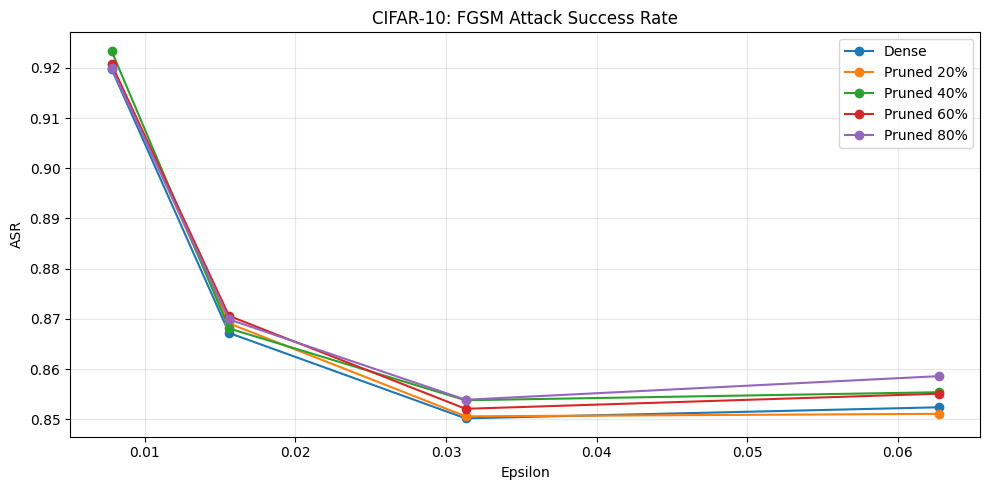

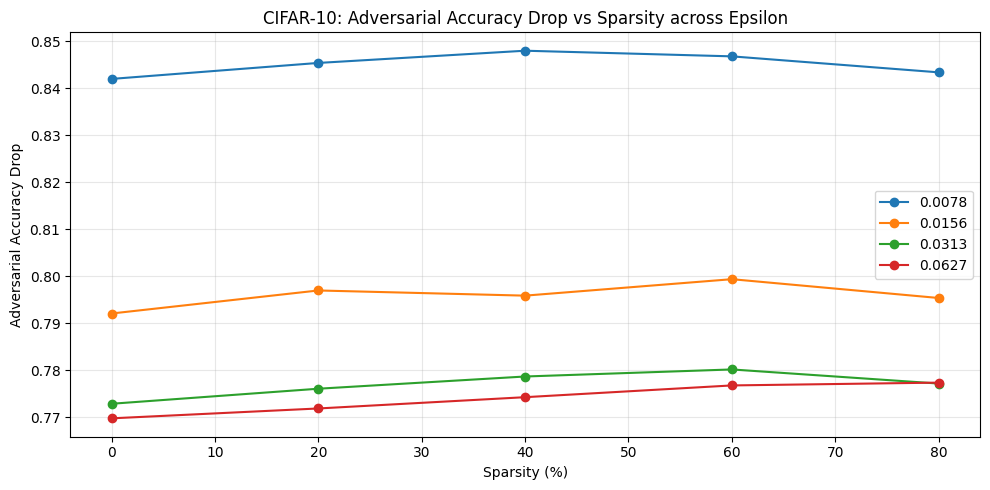

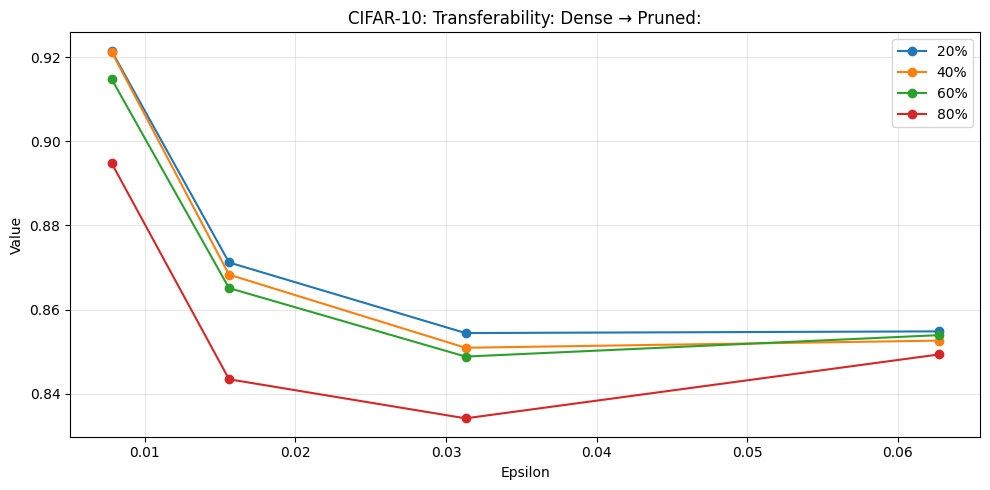

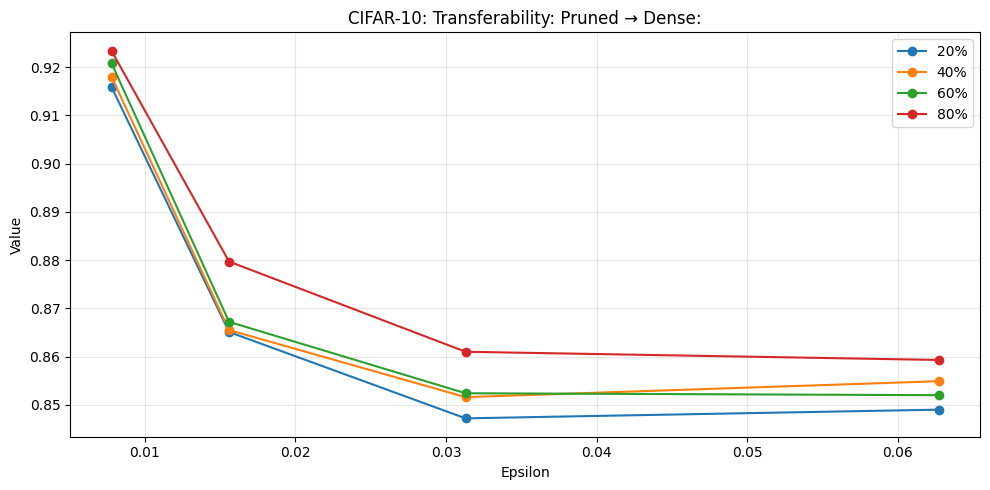

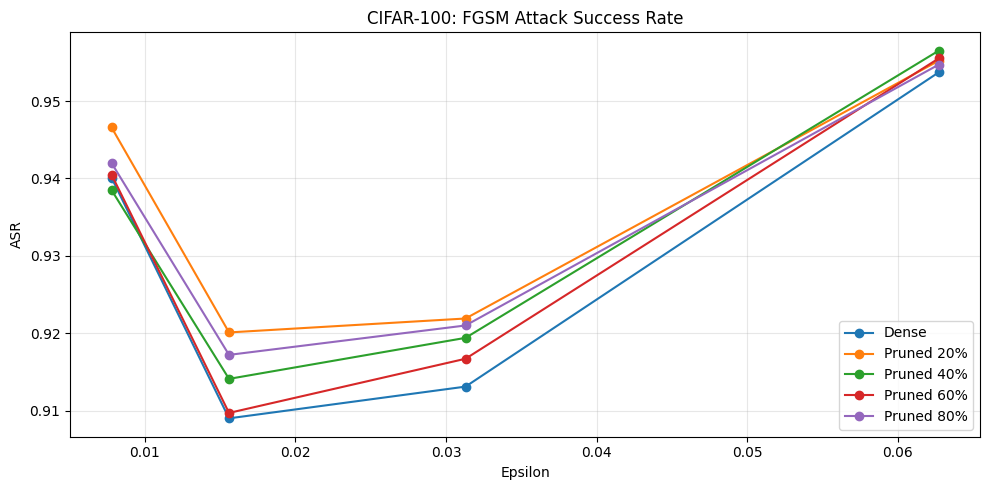

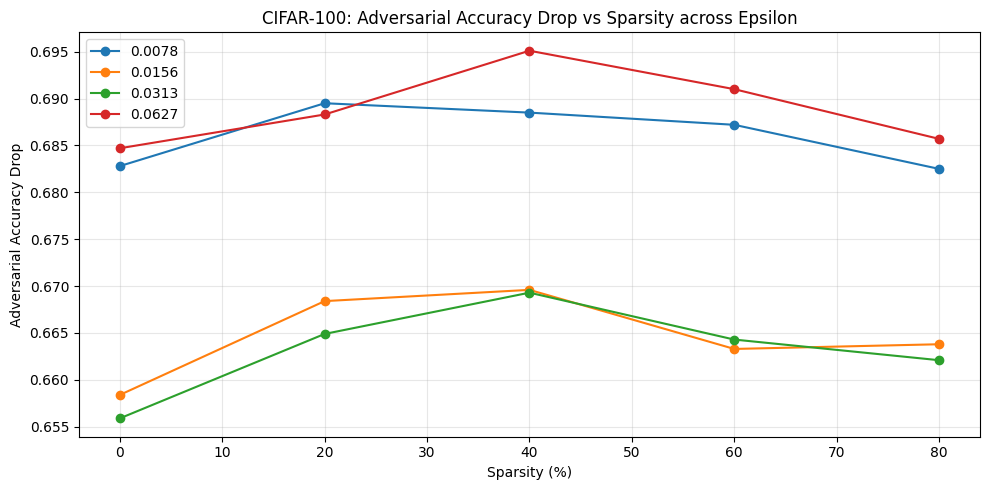

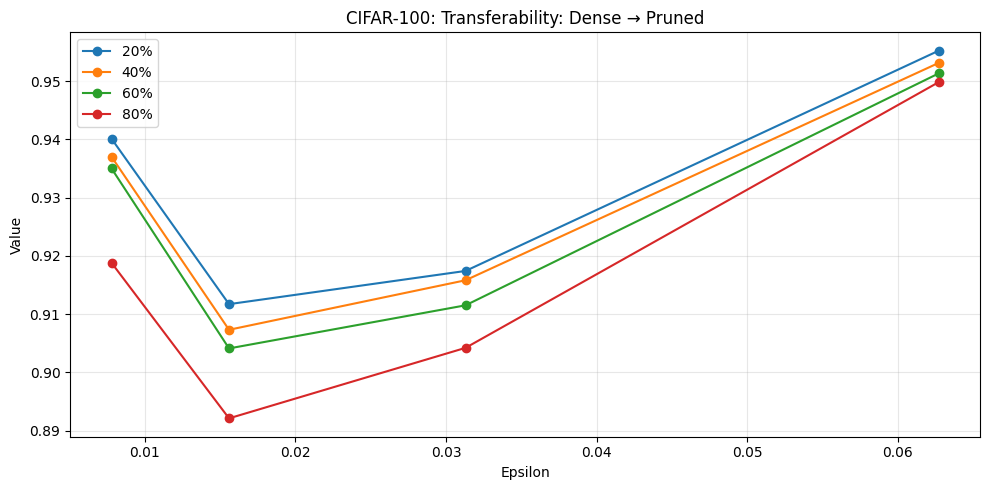

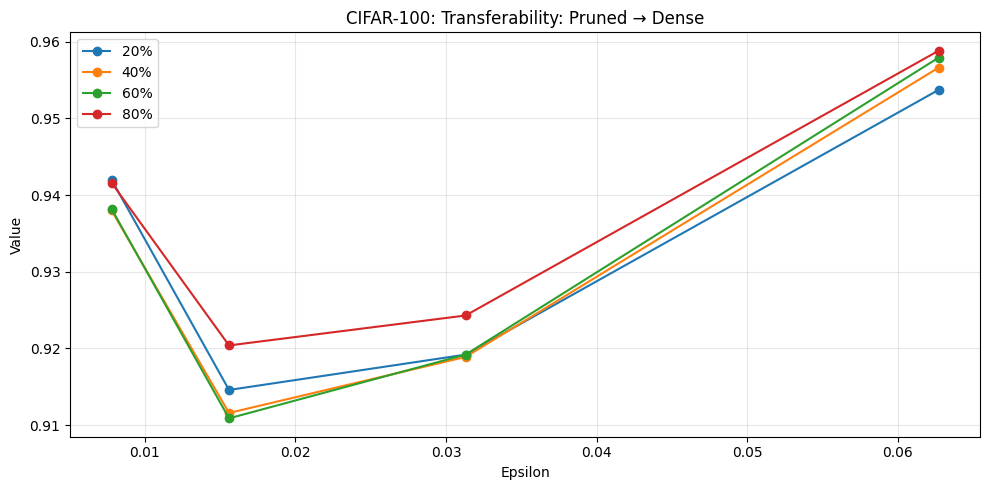

In [20]:

# =========================================================
# File paths
# =========================================================

num_classes = ['10', '100']
models = ['VGG16']
for model in models:
  for num_class in num_classes:

    json_file = f"/content/drive/MyDrive/DLBA_Project/VGG_Result/{model}_T1_C{num_class}_result.json"

    # change if you want a different chosen epsilon
    CHOSEN_EPSILON = 0.0313

    # output folders
    OUT = f"figures/cifar{num_class}"


    # =========================================================
    # Load tables
    # =========================================================

    tables = load_tables(json_file)


    # =========================================================
    # Run old graph codes
    # =========================================================

    run_core_old_plots(
        tables=tables,
        dataset_name=f"CIFAR-{num_class}",
        out_dir=f"{OUT}/old",
        show=True
    )

    # =========================================================
    # Run new graph codes
    # =========================================================

    # run_core_new_plots(
    #     tables=tables,
    #     dataset_name=f"CIFAR-{num_class}",
    #     epsilon=CHOSEN_EPSILON,
    #     out_dir=f"{OUT}/new",
    #     show=True
    # )


    # =========================================================
    # Extra model-specific comparison plots
    # =========================================================

    # # CIFAR-{num_class} examples: Dense and Pruned 80%
    # plot_10_vs_11_vs_initially_correct(
    #     tables, f"CIFAR-{num_class}", "Dense",
    #     output_path=f"{OUT}/new/new_dense_10_vs_11_vs_initial_correct.png",
    #     show=True
    # )

    # plot_10_vs_11_vs_initially_correct(
    #     tables, f"CIFAR-{num_class}", "Pruned 80%",
    #     output_path=f"{OUT}/new/new_pruned80_10_vs_11_vs_initial_correct.png",
    #     show=True
    # )

